# Day 10: Public Leaderboard Challenge

Package multiple local strategies as benchmark submissions and compare them on `public-test`. This notebook is the classroom rehearsal before private-world generalization.

In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(10)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)


project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day10


In [2]:
tu.display_learning_goal(
    10,
    "Public challenge submission",
    [
        "Create several fixed strategy submissions.",
        "Write standard benchmark JSONL trajectories.",
        "Evaluate and verify every trajectory.",
        "Build a public leaderboard table.",
    ],
)

In [3]:
tu.display_api_card()

In [4]:
tu.display_student_checkpoint(
    10,
    [
        "one valid JSONL submission",
        "one evaluation JSON-like table",
        "one replay verification result",
        "one public leaderboard row",
    ],
)

In [5]:
strategies = {
    "conservative": {
        "temperature": 65.0,
        "time": 0.75,
        "initial_concentration": 0.25,
        "stirring_speed": 600.0,
        "catalyst": 1,
        "solvent": 1,
    },
    "balanced": {
        "temperature": 75.0,
        "time": 0.50,
        "initial_concentration": 0.35,
        "stirring_speed": 650.0,
        "catalyst": 1,
        "solvent": 1,
    },
    "aggressive": {
        "temperature": 110.0,
        "time": 0.30,
        "initial_concentration": 0.60,
        "stirring_speed": 900.0,
        "catalyst": 3,
        "solvent": 2,
    },
}
pd.DataFrame(
    [{"strategy": name, **tu.format_recipe(recipe)} for name, recipe in strategies.items()]
)

,strategy,temperature_C,time_h,initial_concentration_M,stirring_rpm,catalyst,solvent
0,conservative,65.0,0.75,0.25,600.0,cat_b,ethanol
1,balanced,75.0,0.50,0.35,650.0,cat_b,ethanol
2,aggressive,110.0,0.30,0.60,900.0,cat_d,acetonitrile


,strategy,trajectory,verified,final_best_score,safety_aware_score,total_score
0,conservative,D:\Projects\ChemWorld\runs\tutorials\day10\con...,True,0.5250,0.5109,0.4128
1,balanced,D:\Projects\ChemWorld\runs\tutorials\day10\bal...,True,0.5162,0.5006,0.4055
2,aggressive,D:\Projects\ChemWorld\runs\tutorials\day10\agg...,True,0.4060,0.3768,0.3156


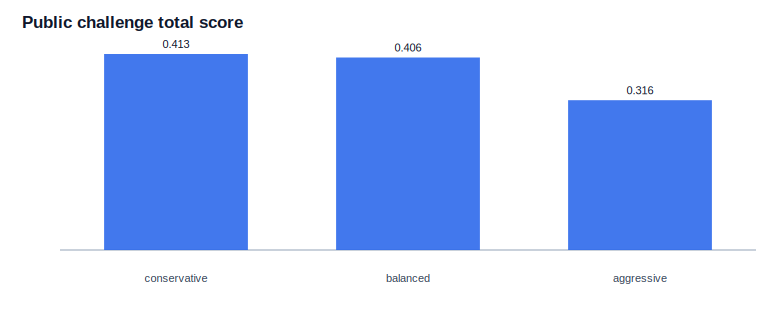

In [6]:
from chemworld.eval.metrics import evaluate_records
from chemworld.eval.verify import verify_records

submission_rows = []
for name, recipe in strategies.items():
    path = OUTPUT_DIR / f"{name}_public_submission.jsonl"
    records = tu.write_recipe_trajectory(
        recipe, path, split="public-test", seed=1000, agent_name=f"public_{name}"
    )
    evaluation = evaluate_records(records).to_dict()
    verification = verify_records(records).to_dict()
    submission_rows.append(
        {
            "strategy": name,
            "trajectory": str(path),
            "verified": verification["verified"],
            "final_best_score": evaluation["final_best_score"],
            "safety_aware_score": evaluation["safety_aware_score"],
            "total_score": evaluation["total_score"],
        }
    )
submissions_df = (
    pd.DataFrame(submission_rows).sort_values("total_score", ascending=False).reset_index(drop=True)
)
display(submissions_df)
display(
    tu.bar_svg(
        submissions_df["strategy"].tolist(),
        submissions_df["total_score"].astype(float).tolist(),
        title="Public challenge total score",
        color="#2563eb",
    )
)

In [7]:
challenge_rules = {
    "allowed_split": "public-test",
    "required_files": ["trajectory JSONL", "agent manifest or strategy note", "explanation"],
    "verification": "verify_records must return verified=True",
    "warning": "Do not tune only for public-test. Day 11 will check private-eval transfer.",
}
tu.show_json_panel("Public challenge rules", challenge_rules)